In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
# Step 1: Load the dataset
df = pd.read_csv("/content/sample_data/HR_comma_sep.csv")

# Step 2: Basic EDA
print(df.head())
print(df.info())
print(df.describe())
print(df['left'].value_counts())  # Target variable: 1 = left, 0 = stayed

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 


Correlation with 'left':
 left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
salary                  -0.157898
satisfaction_level      -0.388375
Name: left, dtype: float64


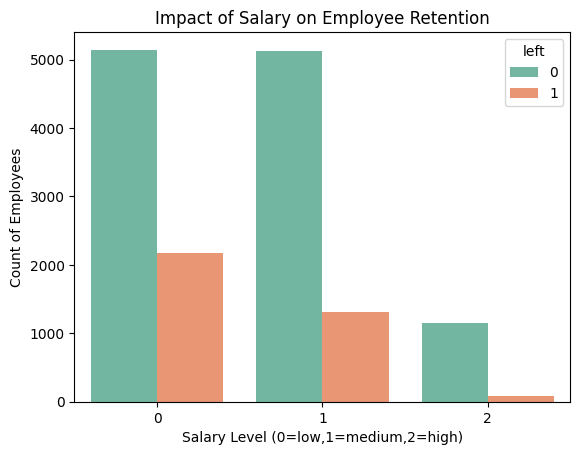

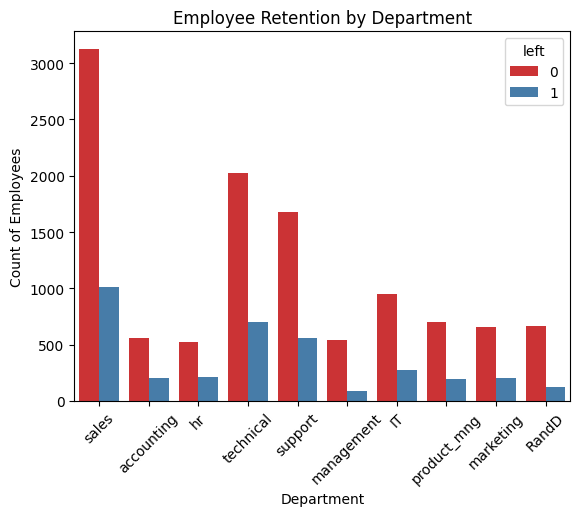


Accuracy of Logistic Regression model: 0.7658

Confusion Matrix:
 [[3172  256]
 [ 798  274]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86      3428
           1       0.52      0.26      0.34      1072

    accuracy                           0.77      4500
   macro avg       0.66      0.59      0.60      4500
weighted avg       0.73      0.77      0.73      4500


Logistic Regression Coefficients:
                    Feature  Coefficient
0       satisfaction_level    -4.113927
6    promotion_last_5years    -1.335497
5                   salary    -0.674107
7         Department_RandD    -0.607865
1          last_evaluation     0.582107
9            Department_hr     0.431575
10   Department_management    -0.374111
2           number_project    -0.288999
4       time_spend_company     0.245905
15    Department_technical     0.234727
11    Department_marketing     0.226837
8    Department_accounting     0.21313

In [11]:

# Step 3: Encode categorical variables
# Map salary to numeric
df['salary'] = df['salary'].map({'low':0, 'medium':1, 'high':2})

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Encode 'Department' column (check correct capitalization)
if 'Department' in df.columns:
    df = pd.get_dummies(df, columns=['Department'], drop_first=True)
else:
    print("'Department' column not found! Columns available:", df.columns.tolist())

# Step 4: Correlation analysis for numeric variables only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
print("\nCorrelation with 'left':\n", corr_matrix['left'].sort_values(ascending=False))

# Step 5: Visualize impact of salary on retention
sns.countplot(x='salary', hue='left', data=df, palette='Set2')
plt.title("Impact of Salary on Employee Retention")
plt.xlabel("Salary Level (0=low,1=medium,2=high)")
plt.ylabel("Count of Employees")
plt.show()

# Step 6: Visualize impact of department on retention
# Use original dataframe (before get_dummies)
sns.countplot(x='Department', hue='left', data=pd.read_csv("/content/sample_data/HR_comma_sep.csv"), palette='Set1')
plt.title("Employee Retention by Department")
plt.xlabel("Department")
plt.ylabel("Count of Employees")
plt.xticks(rotation=45)
plt.show()

# Step 7: Select features for logistic regression
features = ['satisfaction_level', 'last_evaluation', 'number_project',
            'average_montly_hours', 'time_spend_company', 'salary', 'promotion_last_5years']

# Include one-hot encoded department columns if they exist
dept_columns = [col for col in df.columns if col.startswith('Department_')]
features += dept_columns

X = df[features]
y = df['left']

# Step 8: Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 9: Build logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 10: Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of Logistic Regression model: {accuracy:.4f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 11 (Optional): Display logistic regression coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("\nLogistic Regression Coefficients:\n", coefficients)

In [17]:
zoo_df = pd.read_csv("/content/sample_data/zoo-data.csv")        # Main zoo dataset
class_df = pd.read_csv("/content/sample_data/zoo-class-type.csv")  # Class reference

# Step 2: Check the datasets
print("Zoo dataset:")
print(zoo_df.head())
print(zoo_df.info())
print("\nClass type reference:")
print(class_df)

Zoo dataset:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2      


Missing values in zoo dataset:
 animal_name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
class_type     0
dtype: int64

Accuracy of Logistic Regression model: 0.9677

Confusion Matrix:
 [[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  0  0  0  1]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  3]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


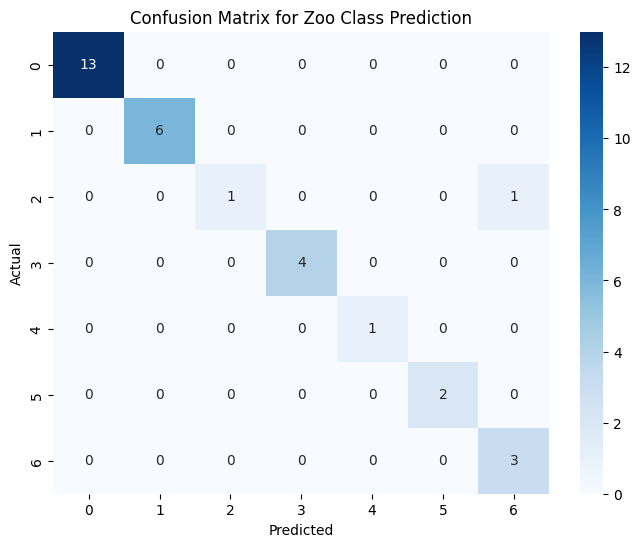


Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3

    accuracy                           0.97        31
   macro avg       0.96      0.93      0.93        31
weighted avg       0.98      0.97      0.96        31



In [23]:
# Step 3: Preprocessing
# Check for missing values
print("\nMissing values in zoo dataset:\n", zoo_df.isnull().sum())

# Encode 'class_type' if it's categorical
if zoo_df['class_type'].dtype == 'object':
    le = LabelEncoder()
    zoo_df['class_type'] = le.fit_transform(zoo_df['class_type'])

# Step 4: Features and target
X = zoo_df.drop(['class_type', 'animal_name'], axis=1, errors='ignore')  # Drop name column if exists
y = zoo_df['class_type']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Step 6: Build logistic regression model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of Logistic Regression model: {accuracy:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Zoo Class Prediction")
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))